# Search: Solving a Maze Using a Goal-based Agent

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for pathfinding in mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

The agent must use a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. This is a planing exercise for a goal-based agent, so you do not need to implement an environment, just use the map to search for a path. Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the path and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. We do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. Here is the small example maze:

In [1]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [2]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

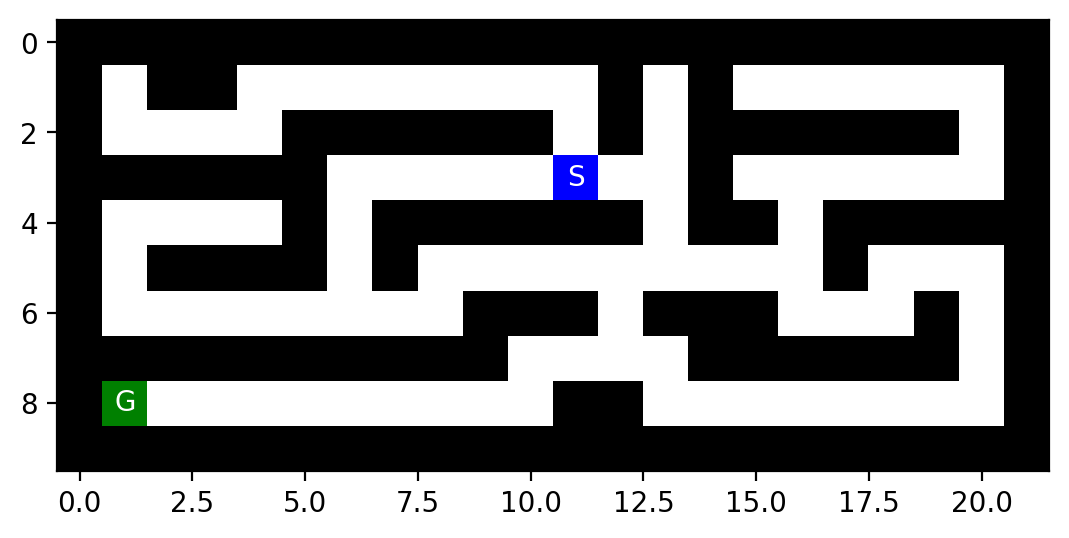

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [4]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [5]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        Build an animation from a list of mazes. Assumes that results has the elements:
        path, reached, actions and maze_anim with a list of maze arrays.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
        maze: a array with characters prodced by parse_maze()
        what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
        a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).

    maze_to_matrix(maze)
        convert a maze a numeric numpy array for visualization via imshow.

    parse_maze(maze_str)
        Co

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## Tree structure

Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [6]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [medium maze](medium_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt),
    - [wall maze](wall_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty 2_maze](empty_2_maze.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can swich the next block from code to Markdown and use formating.

In [7]:
# Your answer goes here
## Task 1: Defining the Search Problem and Determining the Problem Size

### 1. Initial State
# - **Initial state (S):** Vị trí bắt đầu của agent trong mê cung.  
# - Biểu diễn dưới dạng tọa độ `(x_start, y_start)`.

# ---

# ### 2. Actions
# - Agent có thể di chuyển theo **4 hướng**:
#   - Up: `(x, y) → (x-1, y)`
#   - Down: `(x, y) → (x+1, y)`
#   - Left: `(x, y) → (x, y-1)`
#   - Right: `(x, y) → (x, y+1)`
# - Hành động chỉ hợp lệ nếu ô tiếp theo không phải tường (`#`) và nằm trong giới hạn mê cung.

# ---

# ### 3. Transition Model
# - Khi agent ở trạng thái `(x, y)` và thực hiện hành động `a`, nó sẽ chuyển sang trạng thái `(x', y')`:
  
#   \[
#   Result((x,y), a) = (x', y') \quad \text{nếu } (x', y') \in \text{ô hợp lệ}
#   \]

# - Nếu hành động dẫn đến tường hoặc ra ngoài mê cung → không hợp lệ.

# ---

# ### 4. Goal State
# - **Goal state (G):** Vị trí đích trong mê cung.  
# - Biểu diễn dưới dạng tọa độ `(x_goal, y_goal)`.  
# - Agent dừng tìm kiếm khi đạt tới **Goal**.

# ---

# ### 5. Path Cost
# - Mỗi bước di chuyển có chi phí bằng **1**.  
# - Tổng chi phí đường đi là số bước từ `S` đến `G`.

#   \[
#   Cost(path) = \sum_{i=1}^{n} step_i, \quad step_i = 1
#   \]

#   ⇒ `Cost(path) = số bước di chuyển`.

# ---

# ###  Tóm lại
# - **State space** = tất cả các ô hợp lệ trong mê cung.  
# - **Initial state** = vị trí bắt đầu `S`.  
# - **Actions** = {Up, Down, Left, Right}.  
# - **Transition model** = di chuyển đến ô kề hợp lệ.  
# - **Goal state** = vị trí đích `G`.  
# - **Path cost** = số bước đi từ `S` đến `G`.  


Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determin these values for a given maze.

In [8]:
# Your answer goes here
## Ước lượng kích thước bài toán

# ### $n$: State Space Size
# - Tổng số trạng thái hợp lệ (các ô có thể đi được, gồm cả Start và Goal).  
# - Nếu mê cung có kích thước $R \times C$ thì:

#   \[
#   n \leq R \times C
#   \]

# ---

# ### $d$: Depth of the Optimal Solution
# - Độ dài của đường đi ngắn nhất từ $S$ đến $G$.  
# - Có thể xác định bằng cách chạy BFS để tìm shortest path.

# ---

# ### $m$: Maximum Depth of the Tree
# - Độ sâu tối đa mà cây tìm kiếm có thể đạt được.  
# - Trong trường hợp xấu nhất, agent phải thăm toàn bộ các trạng thái hợp lệ.  
# - Khi đó:

#   \[
#   m \leq n
#   \]

# ---

# ### $b$: Maximum Branching Factor
# - Số hành động tối đa có thể thực hiện tại một trạng thái.  
# - Trong mê cung dạng lưới 2D: tối đa 4 hướng di chuyển (Up, Down, Left, Right).  
# - Vậy:

#   \[
#   b \leq 4
#   \]

## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking. 
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

In [9]:
# Your code goes here
from collections import deque

class Node:
    def __init__(self, state, parent=None, action=None, depth=0):
        self.state = state          # trạng thái: (x, y)
        self.parent = parent        # node cha
        self.action = action        # hành động để đi từ cha đến đây
        self.depth = depth          # độ sâu trong cây

    def path(self):
        """ Trả về đường đi từ gốc đến node hiện tại """
        node, p = self, []
        while node:
            p.append(node.state)
            node = node.parent
        return list(reversed(p))


def BFS(initial_state, goal_state, maze):
    """Breadth-first Search với frontier + reached"""
    root = Node(initial_state)
    if root.state == goal_state:
        return root.path()

    frontier = deque([root])       # queue FIFO
    reached = {root.state}         # tập trạng thái đã đạt tới

    while frontier:
        node = frontier.popleft()
        x, y = node.state

        # 4 hướng di chuyển
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)

            # Kiểm tra hợp lệ
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != '#'):
                
                if new_state not in reached:
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    if new_state == goal_state:
                        return child.path()
                    reached.add(new_state)
                    frontier.append(child)

    return None   # không tìm thấy


def DFS(initial_state, goal_state, maze):
    """Depth-first Search với cycle checking"""
    root = Node(initial_state)
    stack = [root]  # dùng stack LIFO

    while stack:
        node = stack.pop()
        if node.state == goal_state:
            return node.path()

        x, y = node.state
        # duyệt 4 hướng
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)

            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != '#'):

                # cycle checking: không quay lại cha
                parent = node.parent
                cycle = False
                while parent:
                    if parent.state == new_state:
                        cycle = True
                        break
                    parent = parent.parent
                if not cycle:
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    stack.append(child)

    return None


How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

In [10]:
# Discussion
### BFS và DFS (không dùng cấu trúc `reached`) xử lý vòng lặp (cycles) như thế nào?

# - **Breadth-First Search (BFS)**  
#   BFS duy trì một tập `reached` (hay `visited`) để lưu lại tất cả các trạng thái đã được khám phá.  
#   - Khi sinh ra một trạng thái mới, BFS kiểm tra xem nó có trong `reached` chưa.  
#   - Nếu có → bỏ qua.  
#   - Nếu chưa có → thêm vào `reached` và đưa vào `frontier`.  
#   Cách này đảm bảo BFS **không bao giờ thăm lại cùng một trạng thái** và do đó **tránh được vòng lặp hoàn toàn**.

# - **Depth-First Search (DFS) không dùng `reached`**  
#   DFS chuẩn không sử dụng tập `reached` để tiết kiệm bộ nhớ.  
#   - Thay vào đó, DFS dùng **kiểm tra chu trình (cycle checking)**: trước khi mở rộng một nút, DFS kiểm tra xem trạng thái mới có xuất hiện trong **đường đi từ gốc đến nút hiện tại** (tức trong các tổ tiên) hay không.  
#   - Nếu có → bỏ qua, tránh việc quay lại vòng lặp.  
#   Cách này giúp DFS **tránh được vòng lặp trực tiếp**, nhưng DFS vẫn có thể không hoàn chỉnh trong không gian tìm kiếm vô hạn.

# **Tóm lại:**  
# - BFS tránh vòng lặp bằng cách lưu tất cả các trạng thái đã thăm trong `reached`.  
# - DFS (không dùng `reached`) chỉ tránh vòng lặp bằng cách **kiểm tra trạng thái trùng lặp trên đường đi hiện tại**.


Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

In [11]:
# Discussion
### Đánh giá tính chất của BFS và DFS

# - **Tính hoàn chỉnh (Complete):**
#   - **BFS:** Hoàn chỉnh. Nếu tồn tại lời giải, BFS chắc chắn tìm thấy vì nó mở rộng các nút theo từng tầng.
#   - **DFS:** Không hoàn chỉnh trong không gian tìm kiếm vô hạn, vì DFS có thể đi sâu vô tận mà không quay lại để tìm lời giải ở nhánh khác.

# - **Tính tối ưu (Optimal):**
#   - **BFS:** Tối ưu nếu chi phí mỗi bước là bằng nhau, vì BFS luôn tìm thấy lời giải ở độ sâu nhỏ nhất.
#   - **DFS:** Không tối ưu, vì DFS có thể tìm thấy một lời giải dài hơn trước khi tìm thấy lời giải ngắn nhất.

# ---

# ### Độ phức tạp thời gian (Time complexity):
# - **BFS:**  
#   - Thời gian: \(O(b^d)\)  
#   Trong đó \(b\) là hệ số phân nhánh (branching factor), \(d\) là độ sâu của lời giải tối ưu.  
# - **DFS:**  
#   - Thời gian: \(O(b^m)\)  
#   Trong đó \(m\) là độ sâu tối đa của cây tìm kiếm.  

# ---

# ### Độ phức tạp bộ nhớ (Space complexity):
# - **BFS:**  
#   - Bộ nhớ: \(O(b^d)\)  
#   Vì BFS phải lưu toàn bộ frontier và tập `reached` của các trạng thái đã thăm ở mỗi mức.  
# - **DFS:**  
#   - Bộ nhớ: \(O(b \cdot m)\)  
#   Vì DFS chỉ cần lưu trữ đường đi hiện tại và các node sinh ra ở một mức độ sâu.  

# ---

# ### 📊 So sánh BFS và DFS về bộ nhớ
# - BFS cần **bộ nhớ theo cấp số mũ** theo độ sâu của lời giải (\(b^d\)), nên có thể nhanh chóng vượt quá dung lượng khả dụng khi không gian trạng thái lớn.  
# - DFS chỉ cần **bộ nhớ tuyến tính** theo độ sâu tối đa của cây (\(b \cdot m\)), nên tiết kiệm hơn nhiều, đặc biệt trong không gian tìm kiếm lớn.


## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides). 

In [12]:
# Your code goes here
import heapq

def manhattan(p1, p2):
    """Hàm heuristic: khoảng cách Manhattan"""
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def greedy_best_first(initial_state, goal_state, maze):
    """Greedy Best-First Search"""
    root = Node(initial_state)
    frontier = [(manhattan(initial_state, goal_state), root)]
    reached = {root.state}

    while frontier:
        _, node = heapq.heappop(frontier)
        if node.state == goal_state:
            return node.path()

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)

            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != '#'):

                if new_state not in reached:
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    reached.add(new_state)
                    heapq.heappush(frontier, (manhattan(new_state, goal_state), child))

    return None


def a_star(initial_state, goal_state, maze):
    """A* Search"""
    root = Node(initial_state)
    frontier = [(manhattan(initial_state, goal_state), 0, root)]  
    reached = {root.state: 0}  # state -> g(n)

    while frontier:
        f, g, node = heapq.heappop(frontier)
        if node.state == goal_state:
            return node.path()

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)

            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != '#'):

                new_g = g + 1
                if new_state not in reached or new_g < reached[new_state]:
                    reached[new_state] = new_g
                    f = new_g + manhattan(new_state, goal_state)
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    heapq.heappush(frontier, (f, new_g, child))

    return None


Are your implementations complete and optimal? What is the time and space complexity?

In [13]:
# Discussion

# - **Greedy Best-First Search (GBFS)**  
#   - *Đầy đủ (Complete)*: **Không đầy đủ** trong mọi trường hợp, vì có thể mắc kẹt trong các vòng lặp hoặc chọn nhánh sai mà không bao giờ đến đích (phụ thuộc vào heuristic).  
#   - *Tối ưu (Optimal)*: **Không tối ưu**, vì chỉ chọn trạng thái "có vẻ gần đích nhất" theo $h(n)$ mà không xét chi phí đường đi $g(n)$.  
#   - *Độ phức tạp*:  
#     - Thời gian: $O(b^d)$ trong trường hợp xấu nhất (tương tự BFS, vì có thể mở rộng rất nhiều node trước khi tới đích).  
#     - Không gian: $O(b^d)$, cần lưu toàn bộ frontier và reached.  

# - **A\***  
#   - *Đầy đủ (Complete)*: **Có đầy đủ** nếu heuristic **chấp nhận được** (admissible) và không gian tìm kiếm là hữu hạn.  
#   - *Tối ưu (Optimal)*: **Có tối ưu** nếu heuristic vừa chấp nhận được (admissible) vừa nhất quán (consistent). Manhattan distance trong maze là một heuristic chấp nhận được → A* tìm ra đường đi ngắn nhất.  
#   - *Độ phức tạp*:  
#     - Thời gian: $O(b^d)$ trong trường hợp xấu nhất, nhưng thường ít node hơn BFS nhờ heuristic.  
#     - Không gian: $O(b^d)$ vì vẫn cần lưu nhiều node trong frontier và reached.  

# **Ký hiệu:**  
# - `b`: hệ số phân nhánh lớn nhất (branching factor).  
# - `d`: độ sâu của lời giải tối ưu.  

# **So sánh chính:**  
# - GBFS: nhanh hơn trong một số trường hợp, nhưng không đảm bảo tìm được lời giải tối ưu.  
# - A*: chậm hơn và tốn bộ nhớ hơn, nhưng đảm bảo *đầy đủ* và *tối ưu* với heuristic Manhattan.


## Task 4: Comparison and discussion [20 Points] 

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [14]:
import heapq
from collections import deque

# Node class giữ nguyên
class Node:
    def __init__(self, state, parent=None, action=None, depth=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.depth = depth

    def path(self):
        node, p = self, []
        while node:
            p.append(node.state)
            node = node.parent
        return list(reversed(p))


# ----- BFS -----
def BFS_stats(initial_state, goal_state, maze):
    root = Node(initial_state)
    frontier = deque([root])
    reached = {root.state}
    expanded, max_depth = 0, 0
    max_frontier, max_memory = 1, 1

    while frontier:
        node = frontier.popleft()
        expanded += 1
        max_depth = max(max_depth, node.depth)
        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(frontier) + len(reached))

        if node.state == goal_state:
            path = node.path()
            return {
                "path_cost": len(path) - 1,
                "nodes_expanded": expanded,
                "max_tree_depth": max_depth,
                "max_memory": max_memory,
                "max_frontier": max_frontier,
                "path": path
            }

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != 'X'):
                if new_state not in reached:
                    reached.add(new_state)
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    frontier.append(child)
    return None


# ----- DFS -----
def DFS_stats(initial_state, goal_state, maze):
    root = Node(initial_state)
    stack = [root]
    expanded, max_depth = 0, 0
    max_frontier, max_memory = 1, 1

    while stack:
        node = stack.pop()
        expanded += 1
        max_depth = max(max_depth, node.depth)
        max_frontier = max(max_frontier, len(stack))
        max_memory = max(max_memory, len(stack))

        if node.state == goal_state:
            path = node.path()
            return {
                "path_cost": len(path) - 1,
                "nodes_expanded": expanded,
                "max_tree_depth": max_depth,
                "max_memory": max_memory,
                "max_frontier": max_frontier,
                "path": path
            }

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != 'X'):
                # cycle check
                parent, cycle = node.parent, False
                while parent:
                    if parent.state == new_state:
                        cycle = True
                        break
                    parent = parent.parent
                if not cycle:
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    stack.append(child)
    return None


# ----- Greedy Best-First -----
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def greedy_best_first_stats(initial_state, goal_state, maze):
    root = Node(initial_state)
    counter = 0
    frontier = [(manhattan(initial_state, goal_state), counter, root)]
    reached = {root.state}
    expanded, max_depth = 0, 0
    max_frontier, max_memory = 1, 1

    while frontier:
        _, _, node = heapq.heappop(frontier)
        expanded += 1
        max_depth = max(max_depth, node.depth)
        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(frontier) + len(reached))

        if node.state == goal_state:
            path = node.path()
            return {
                "path_cost": len(path) - 1,
                "nodes_expanded": expanded,
                "max_tree_depth": max_depth,
                "max_memory": max_memory,
                "max_frontier": max_frontier,
                "path": path
            }

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != 'X'):
                if new_state not in reached:
                    reached.add(new_state)
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    counter += 1
                    heapq.heappush(frontier, (manhattan(new_state, goal_state), counter, child))
    return None



# ----- A* -----
def a_star_stats(initial_state, goal_state, maze):
    root = Node(initial_state)
    counter = 0
    frontier = [(manhattan(initial_state, goal_state), counter, 0, root)]
    reached = {root.state: 0}
    expanded, max_depth = 0, 0
    max_frontier, max_memory = 1, 1

    while frontier:
        f, _, g, node = heapq.heappop(frontier)
        expanded += 1
        max_depth = max(max_depth, node.depth)
        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(frontier) + len(reached))

        if node.state == goal_state:
            path = node.path()
            return {
                "path_cost": len(path) - 1,
                "nodes_expanded": expanded,
                "max_tree_depth": max_depth,
                "max_memory": max_memory,
                "max_frontier": max_frontier,
                "path": path
            }

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != 'X'):
                new_g = g + 1
                if new_state not in reached or new_g < reached[new_state]:
                    reached[new_state] = new_g
                    f = new_g + manhattan(new_state, goal_state)
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    counter += 1
                    heapq.heappush(frontier, (f, counter, new_g, child))
    return None


def read_maze_from_file(path):
    maze = []
    start, goal = None, None
    with open(path, "r") as f:
        for i, line in enumerate(f):
            row = list(line.rstrip("\n"))
            for j, cell in enumerate(row):
                if cell == "S":
                    start = (i, j)
                    row[j] = " "
                elif cell == "G":
                    goal = (i, j)
                    row[j] = " "
            maze.append(row)
    return maze, start, goal


# Small maze
maze, start, goal = read_maze_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/small_maze.txt")

results = {
    "BFS": BFS_stats(start, goal, maze),
    "DFS": DFS_stats(start, goal, maze),
    "Greedy": greedy_best_first_stats(start, goal, maze),
    "A*": a_star_stats(start, goal, maze)
}

print("So sánh các thuật toán trên small_maze.txt")
print("Thuật toán | Path cost | Expanded | Max depth | Max memory | Max frontier")
print("---------------------------------------------------------------------------")
for name, stats in results.items():
    if stats:
        print(f"{name:9s} | {stats['path_cost']:9d} | {stats['nodes_expanded']:8d} | {stats['max_tree_depth']:9d} | {stats['max_memory']:10d} | {stats['max_frontier']:12d}")
    else:
        print(f"{name:9s} | N/A")


# Medium maze
maze, start, goal = read_maze_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/medium_maze.txt")

results = {
    "BFS": BFS_stats(start, goal, maze),
    "DFS": DFS_stats(start, goal, maze),
    "Greedy": greedy_best_first_stats(start, goal, maze),
    "A*": a_star_stats(start, goal, maze)
}

print("\nSo sánh các thuật toán trên medium_maze.txt")
print("Thuật toán | Path cost | Expanded | Max depth | Max memory | Max frontier")
print("---------------------------------------------------------------------------")
for name, stats in results.items():
    if stats:
        print(f"{name:9s} | {stats['path_cost']:9d} | {stats['nodes_expanded']:8d} | {stats['max_tree_depth']:9d} | {stats['max_memory']:10d} | {stats['max_frontier']:12d}")
    else:
        print(f"{name:9s} | N/A")


# Large maze
maze, start, goal = read_maze_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/large_maze.txt")

results = {
    "BFS": BFS_stats(start, goal, maze),
    "DFS": DFS_stats(start, goal, maze),
    "Greedy": greedy_best_first_stats(start, goal, maze),
    "A*": a_star_stats(start, goal, maze)
}

print("\nSo sánh các thuật toán trên large_maze.txt")
print("Thuật toán | Path cost | Expanded | Max depth | Max memory | Max frontier")
print("---------------------------------------------------------------------------")
for name, stats in results.items():
    if stats:
        print(f"{name:9s} | {stats['path_cost']:9d} | {stats['nodes_expanded']:8d} | {stats['max_tree_depth']:9d} | {stats['max_memory']:10d} | {stats['max_frontier']:12d}")
    else:
        print(f"{name:9s} | N/A")



So sánh các thuật toán trên small_maze.txt
Thuật toán | Path cost | Expanded | Max depth | Max memory | Max frontier
---------------------------------------------------------------------------
BFS       |        19 |       92 |        19 |         94 |            7
DFS       |        37 |       38 |        37 |          6 |            6
Greedy    |        29 |       40 |        29 |         48 |            4
A*        |        19 |       54 |        19 |         65 |            7

So sánh các thuật toán trên medium_maze.txt
Thuật toán | Path cost | Expanded | Max depth | Max memory | Max frontier
---------------------------------------------------------------------------
BFS       |        40 |      147 |        40 |        155 |            7
DFS       |       110 |      286 |       183 |          9 |            9
Greedy    |        40 |       45 |        40 |         51 |            4
A*        |        40 |       69 |        40 |         73 |            4

So sánh các thuật toán trên

Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)). 

Đang xử lý Small Maze...
Small Maze Results:
       path_cost nodes_expanded max_tree_depth max_memory max_frontier
BFS           19             92             19         94            7
DFS           37             38             37          6            6
Greedy        29             40             29         48            4
A*            19             54             19         65            7


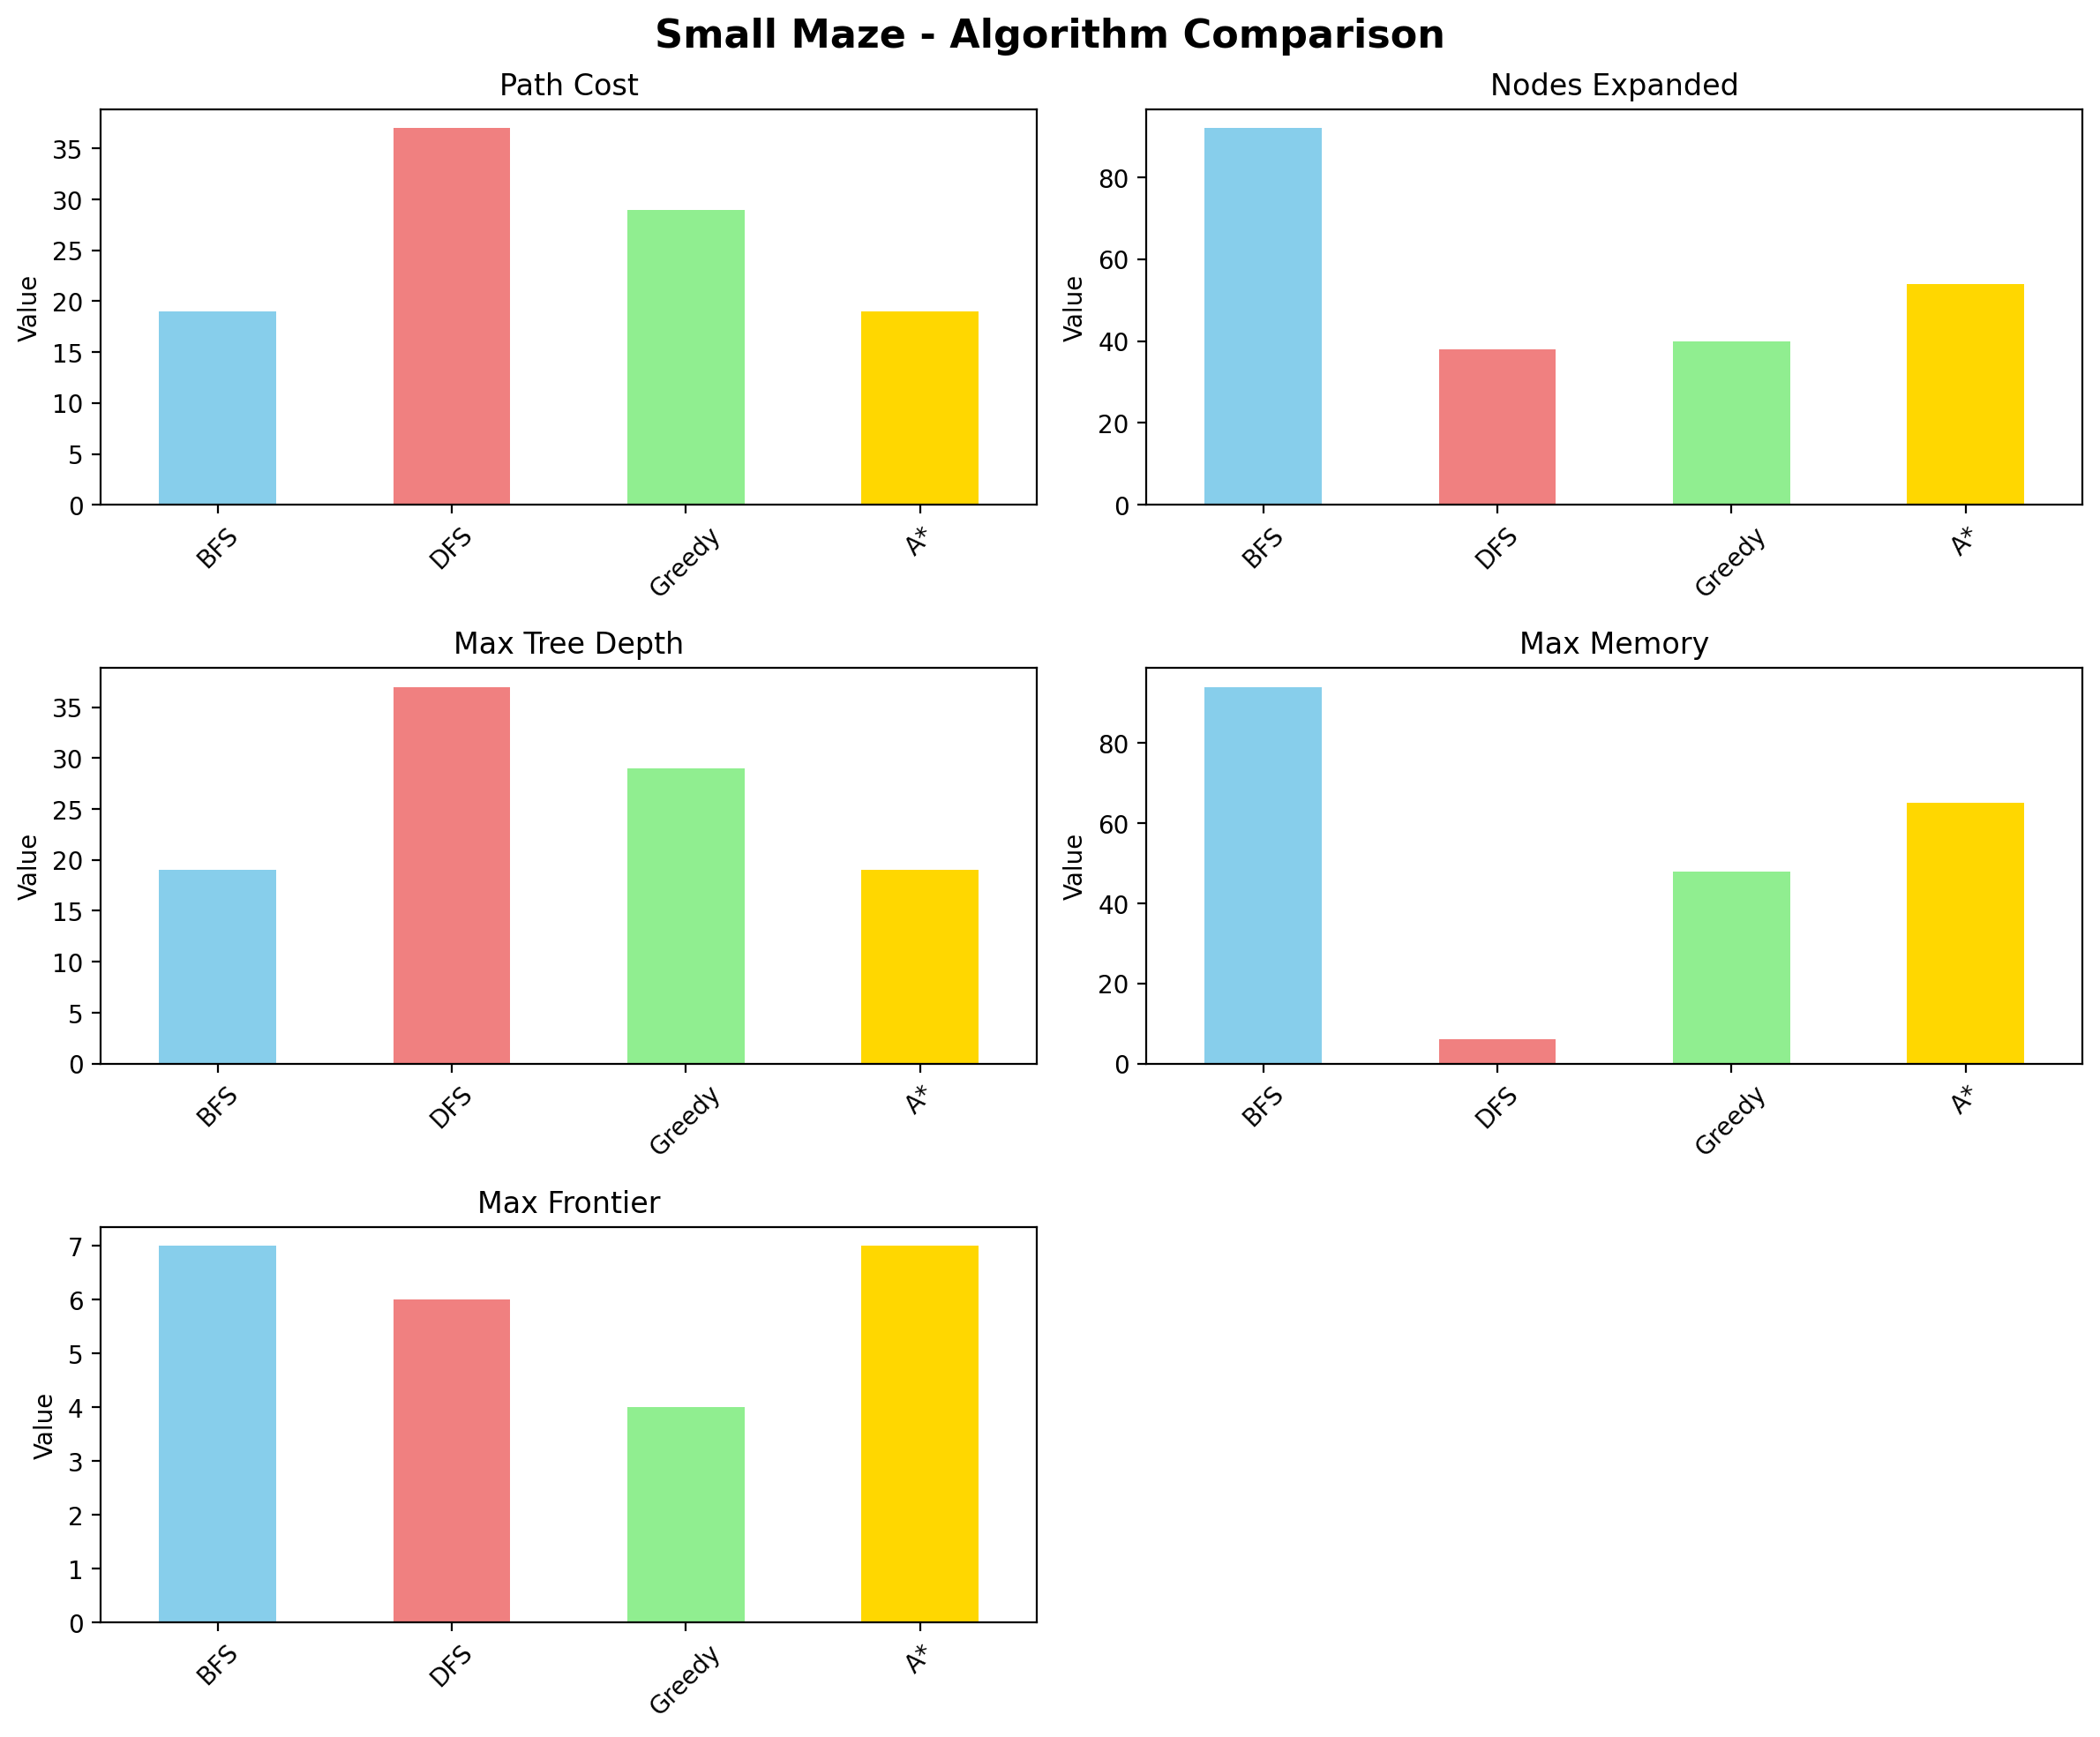


Đang xử lý Medium Maze...
Medium Maze Results:
       path_cost nodes_expanded max_tree_depth max_memory max_frontier
BFS           40            147             40        155            7
DFS          110            286            183          9            9
Greedy        40             45             40         51            4
A*            40             69             40         73            4


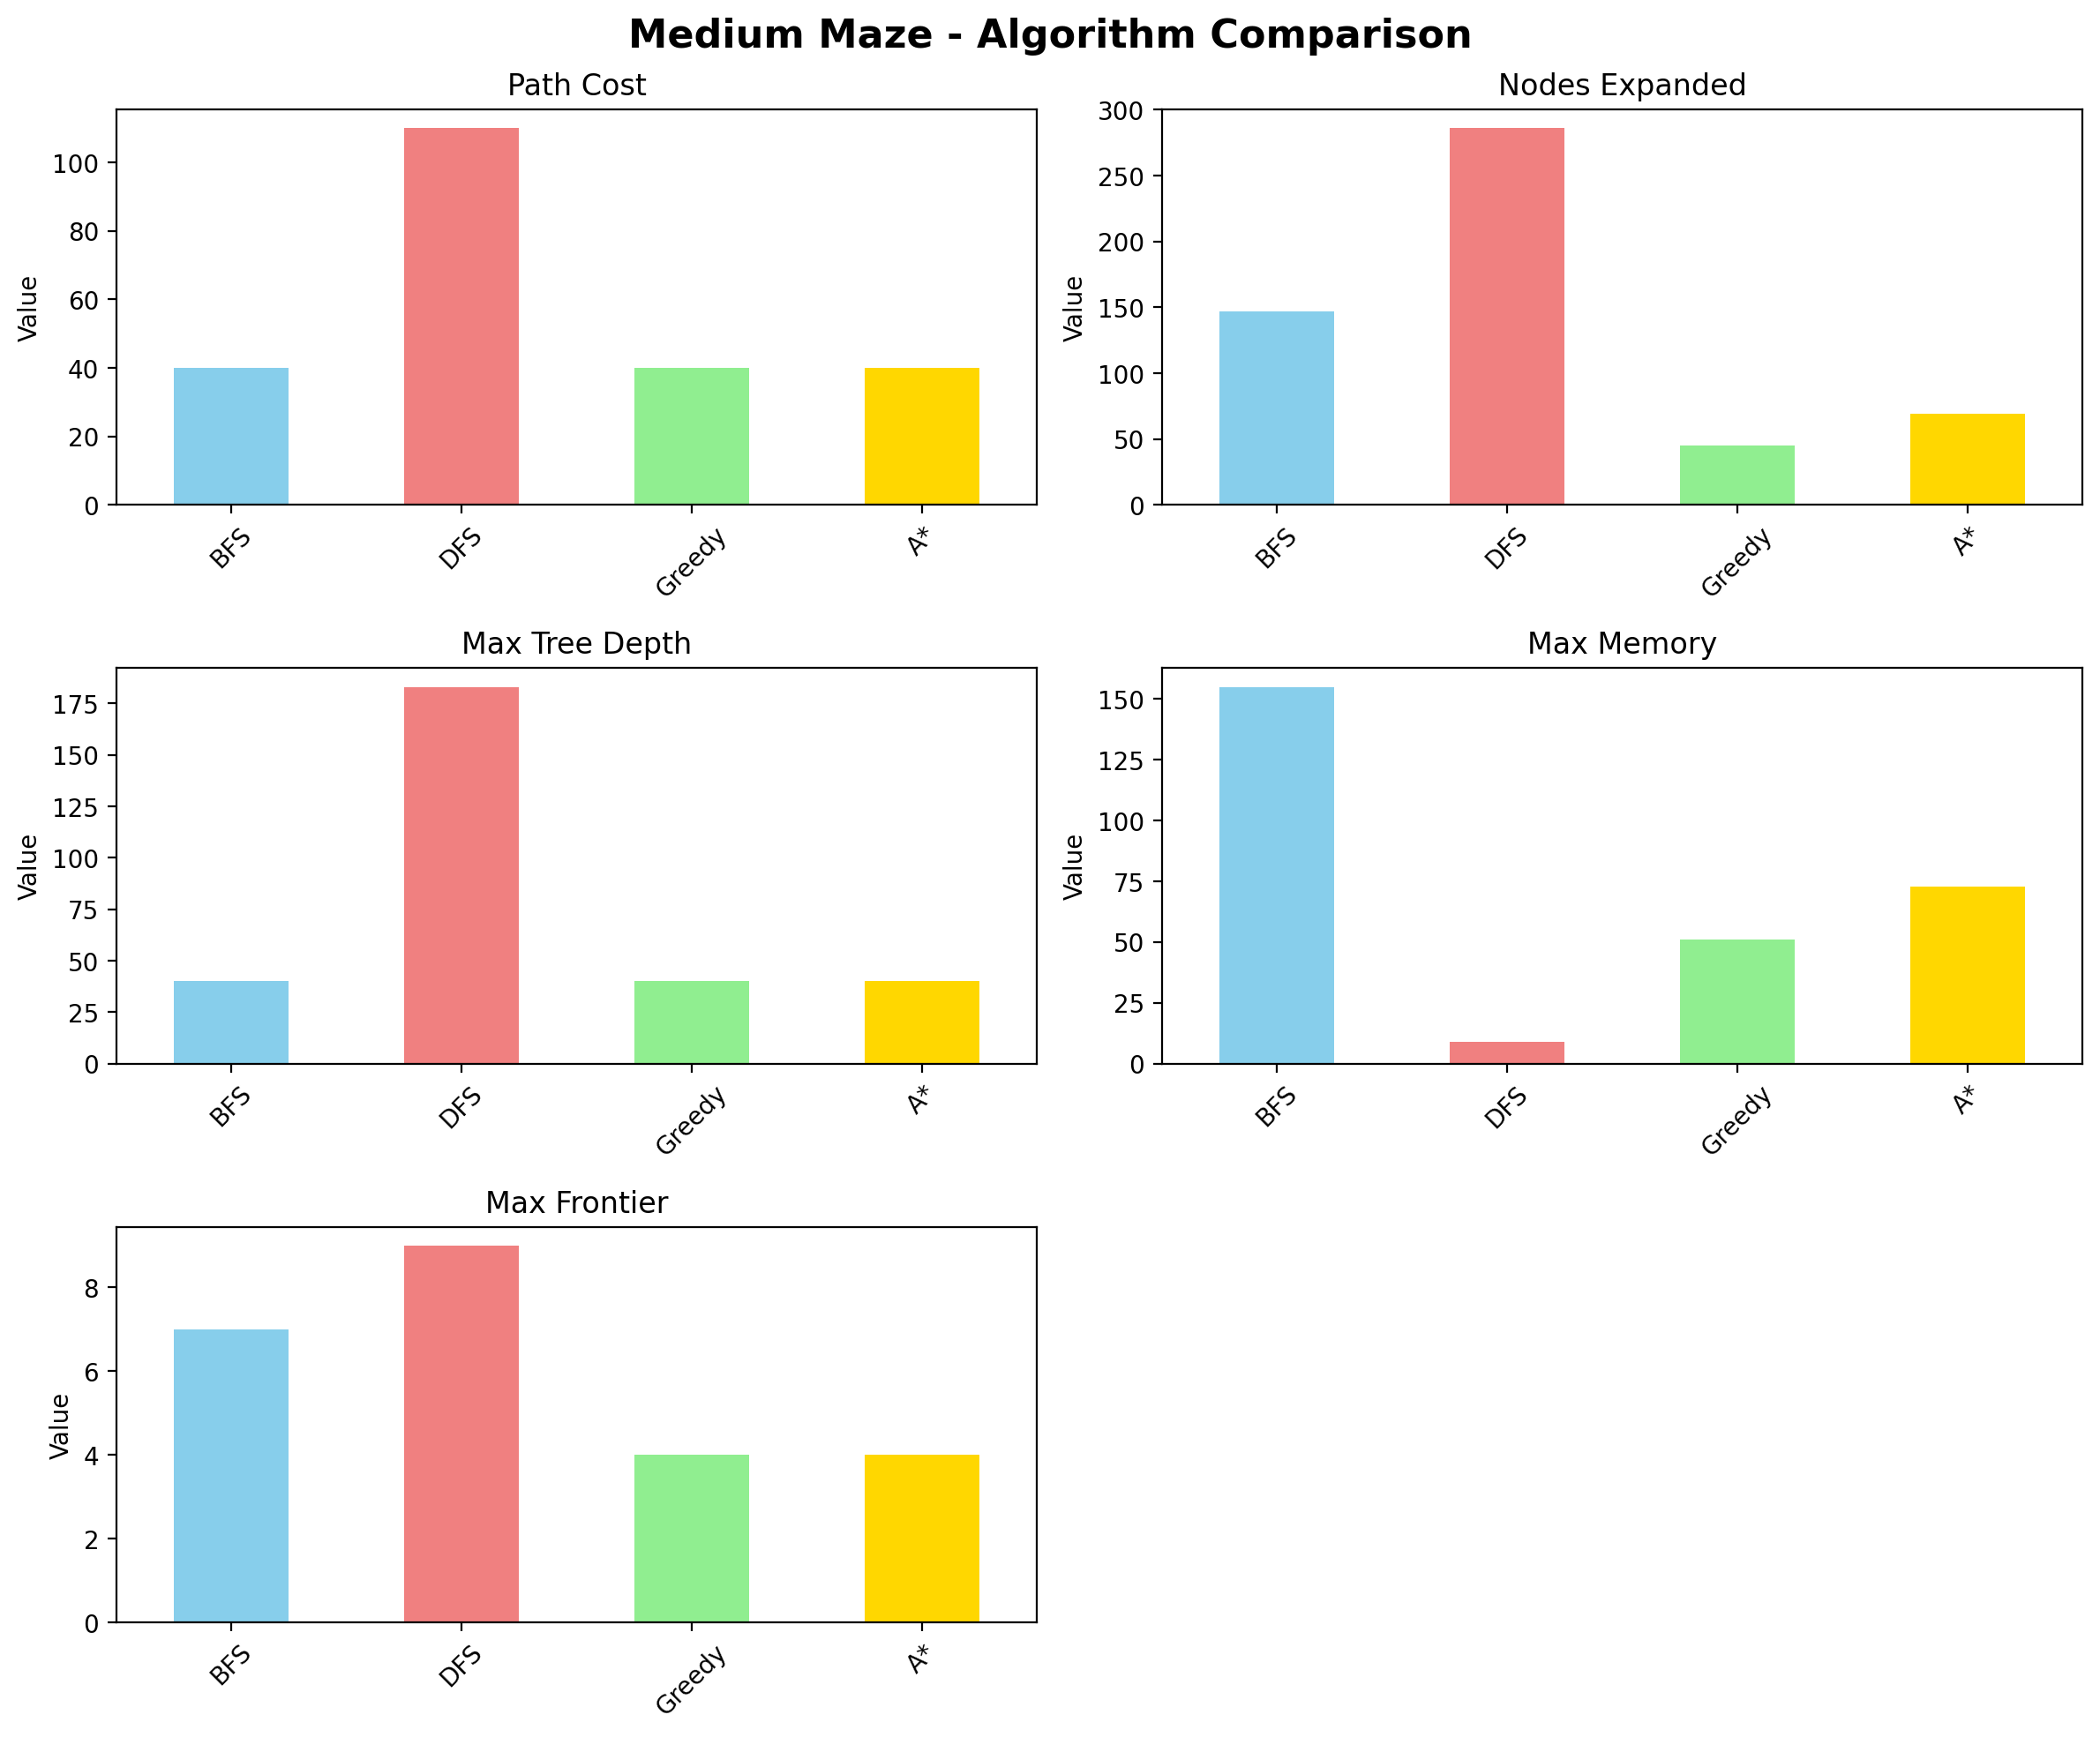


Đang xử lý Large Maze...
Large Maze Results:
       path_cost nodes_expanded max_tree_depth max_memory max_frontier
BFS          210            621            210        626            7
DFS          210            388            222         38           38
Greedy       210            467            210        507           20
A*           210            550            210        564           11


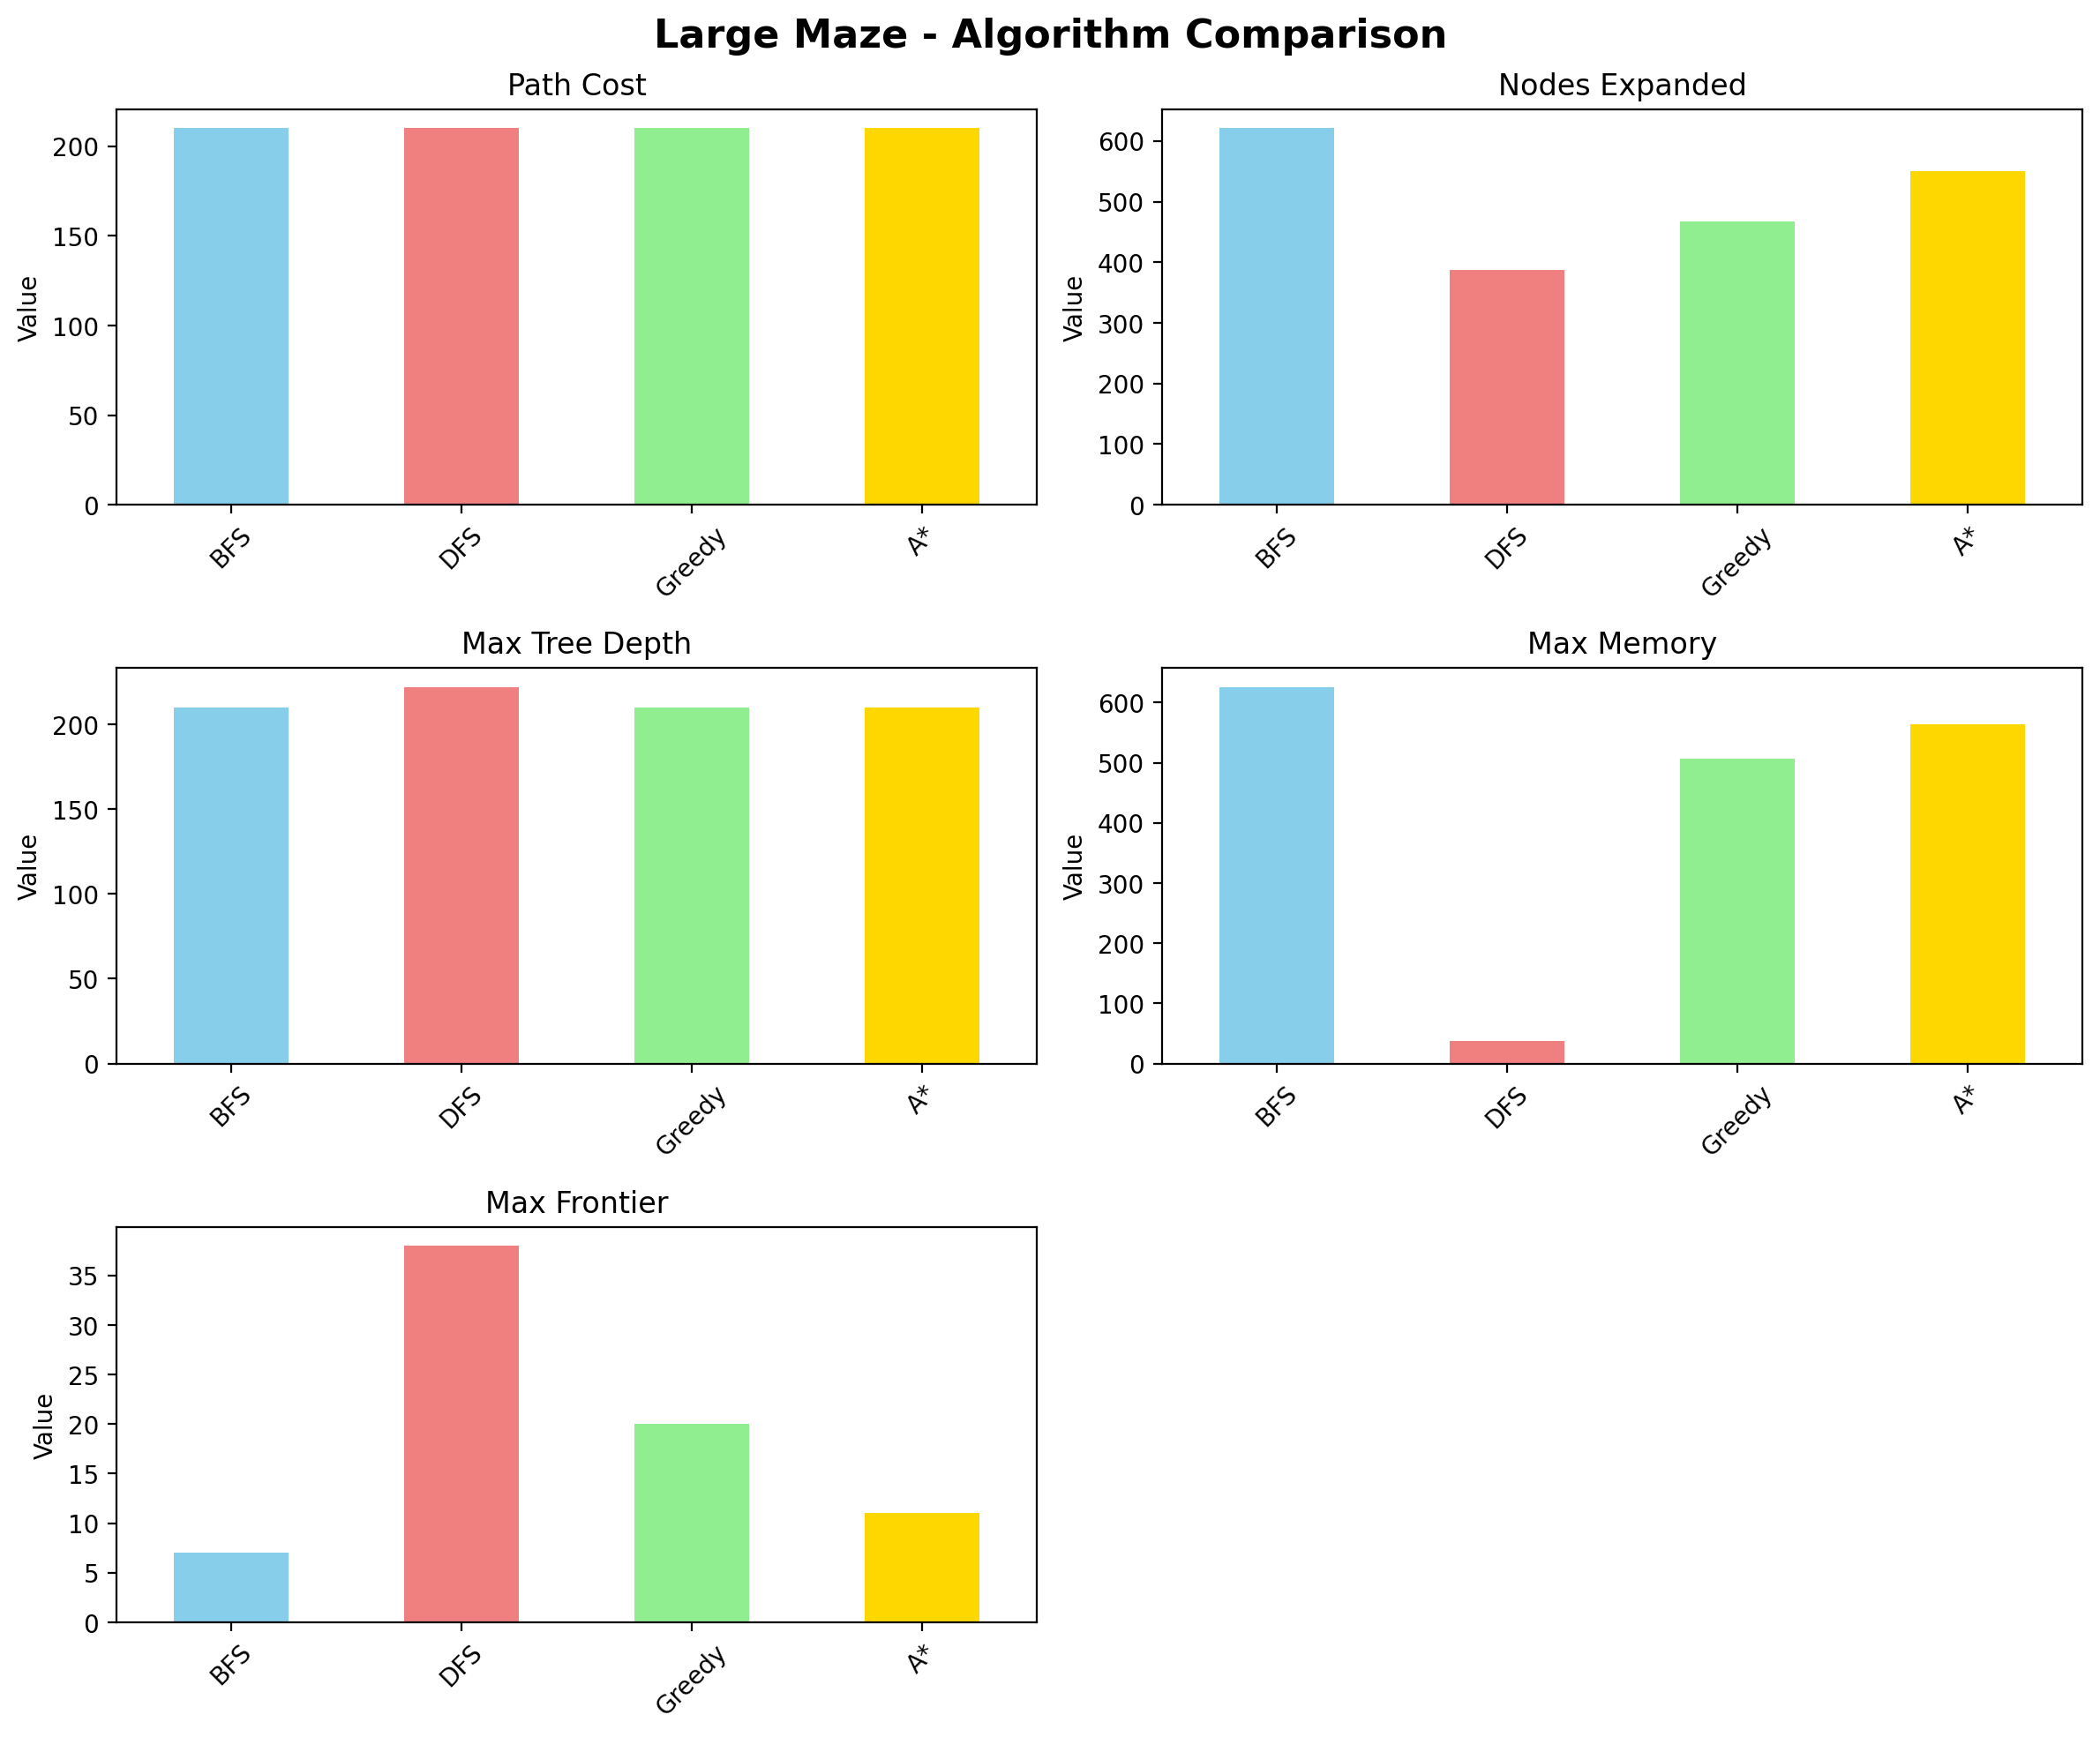


Tạo biểu đồ so sánh tổng hợp...


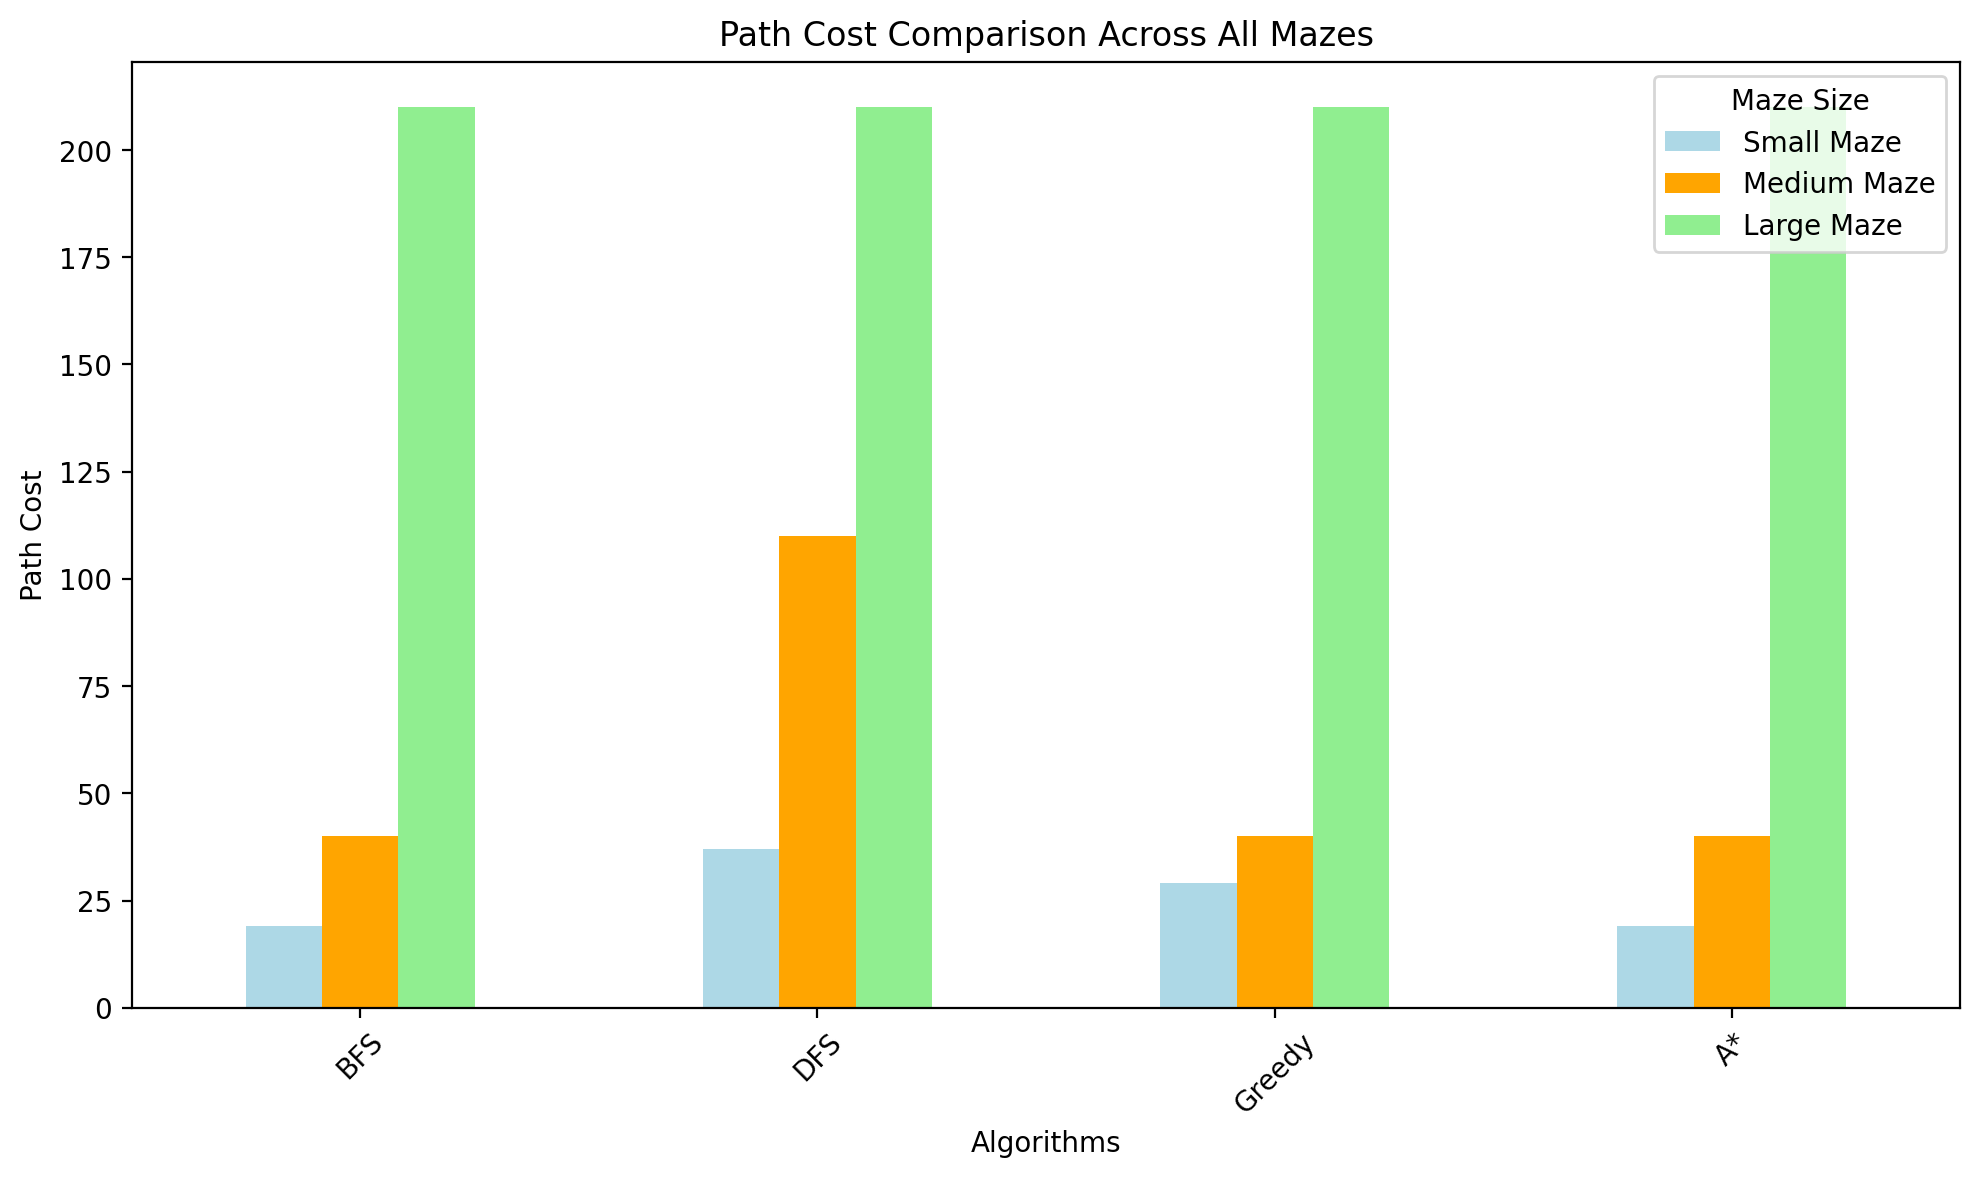

Hoàn thành tất cả biểu đồ!


In [15]:
# Add charts
import matplotlib.pyplot as plt
import pandas as pd


def read_maze_from_file(path):
    maze = []
    start, goal = None, None
    with open(path, "r") as f:
        for i, line in enumerate(f):
            row = list(line.rstrip("\n"))
            for j, cell in enumerate(row):
                if cell == "S":
                    start = (i, j)
                    row[j] = " "
                elif cell == "G":
                    goal = (i, j)
                    row[j] = " "
            maze.append(row)
    return maze, start, goal


# Small maze
print("Đang xử lý Small Maze...")
maze, start, goal = read_maze_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/small_maze.txt")

results_small = {
    "BFS": BFS_stats(start, goal, maze),
    "DFS": DFS_stats(start, goal, maze),
    "Greedy": greedy_best_first_stats(start, goal, maze),
    "A*": a_star_stats(start, goal, maze)
}

# Chuyển về DataFrame để tiện plot
df_small = pd.DataFrame(results_small).T[["path_cost", "nodes_expanded", "max_tree_depth", "max_memory", "max_frontier"]]
print("Small Maze Results:")
print(df_small)

# Vẽ biểu đồ cột cho Small Maze
fig1, axes1 = plt.subplots(3, 2, figsize=(12, 10))
axes1 = axes1.flatten()
fig1.suptitle("Small Maze - Algorithm Comparison", fontsize=16, fontweight='bold')

for i, col in enumerate(df_small.columns):
    df_small[col].plot(kind="bar", ax=axes1[i], title=col.replace('_', ' ').title(), legend=False, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    axes1[i].set_ylabel("Value")
    axes1[i].tick_params(axis='x', rotation=45)

# Tắt ô trống nếu số biểu đồ lẻ
for j in range(len(df_small.columns), len(axes1)):
    fig1.delaxes(axes1[j])

plt.tight_layout()
plt.show()


# Medium maze
print("\nĐang xử lý Medium Maze...")
maze, start, goal = read_maze_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/medium_maze.txt")

results_medium = {
    "BFS": BFS_stats(start, goal, maze),
    "DFS": DFS_stats(start, goal, maze),
    "Greedy": greedy_best_first_stats(start, goal, maze),
    "A*": a_star_stats(start, goal, maze)
}

# Chuyển về DataFrame để tiện plot
df_medium = pd.DataFrame(results_medium).T[["path_cost", "nodes_expanded", "max_tree_depth", "max_memory", "max_frontier"]]
print("Medium Maze Results:")
print(df_medium)

# Vẽ biểu đồ cột cho Medium Maze
fig2, axes2 = plt.subplots(3, 2, figsize=(12, 10))
axes2 = axes2.flatten()
fig2.suptitle("Medium Maze - Algorithm Comparison", fontsize=16, fontweight='bold')

for i, col in enumerate(df_medium.columns):
    df_medium[col].plot(kind="bar", ax=axes2[i], title=col.replace('_', ' ').title(), legend=False, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    axes2[i].set_ylabel("Value")
    axes2[i].tick_params(axis='x', rotation=45)

# Tắt ô trống nếu số biểu đồ lẻ
for j in range(len(df_medium.columns), len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()
plt.show()


# Large maze
print("\nĐang xử lý Large Maze...")
maze, start, goal = read_maze_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/large_maze.txt")

results_large = {
    "BFS": BFS_stats(start, goal, maze),
    "DFS": DFS_stats(start, goal, maze),
    "Greedy": greedy_best_first_stats(start, goal, maze),
    "A*": a_star_stats(start, goal, maze)
}

# Chuyển về DataFrame để tiện plot
df_large = pd.DataFrame(results_large).T[["path_cost", "nodes_expanded", "max_tree_depth", "max_memory", "max_frontier"]]
print("Large Maze Results:")
print(df_large)

# Vẽ biểu đồ cột cho Large Maze
fig3, axes3 = plt.subplots(3, 2, figsize=(12, 10))
axes3 = axes3.flatten()
fig3.suptitle("Large Maze - Algorithm Comparison", fontsize=16, fontweight='bold')

for i, col in enumerate(df_large.columns):
    df_large[col].plot(kind="bar", ax=axes3[i], title=col.replace('_', ' ').title(), legend=False, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    axes3[i].set_ylabel("Value")
    axes3[i].tick_params(axis='x', rotation=45)

# Tắt ô trống nếu số biểu đồ lẻ
for j in range(len(df_large.columns), len(axes3)):
    fig3.delaxes(axes3[j])

plt.tight_layout()
plt.show()


# Bonus: So sánh tổng hợp 3 maze sizes
print("\nTạo biểu đồ so sánh tổng hợp...")

# Tạo DataFrame tổng hợp
comparison_data = {
    'Small Maze': [df_small.loc[alg, 'path_cost'] for alg in ['BFS', 'DFS', 'Greedy', 'A*']],
    'Medium Maze': [df_medium.loc[alg, 'path_cost'] for alg in ['BFS', 'DFS', 'Greedy', 'A*']],
    'Large Maze': [df_large.loc[alg, 'path_cost'] for alg in ['BFS', 'DFS', 'Greedy', 'A*']]
}

df_comparison = pd.DataFrame(comparison_data, index=['BFS', 'DFS', 'Greedy', 'A*'])

# Vẽ biểu đồ so sánh path cost across all mazes
fig4, ax4 = plt.subplots(1, 1, figsize=(10, 6))
df_comparison.plot(kind='bar', ax=ax4, title='Path Cost Comparison Across All Mazes', 
                   color=['lightblue', 'orange', 'lightgreen'])
ax4.set_ylabel('Path Cost')
ax4.set_xlabel('Algorithms')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Maze Size')
plt.tight_layout()
plt.show()

print("Hoàn thành tất cả biểu đồ!")


Discuss the most important lessons you have learned from implementing the different search strategies. 

In [16]:
# Add discussion
### Discussion: Lessons Learned from Implementing Search Strategies

# Qua việc cài đặt và so sánh các thuật toán tìm kiếm (BFS, DFS, Greedy Best-First, A*), em rút ra được một số bài học quan trọng:

# 1. **Sự khác biệt giữa tìm kiếm không thông tin (uninformed) và có thông tin (informed)**  
#    - BFS và DFS không sử dụng thông tin về đích → phải mở rộng nhiều node, dễ tốn bộ nhớ hoặc thời gian.  
#    - Greedy và A* dùng heuristic (khoảng cách Manhattan) nên dẫn đường tốt hơn, đặc biệt A* đảm bảo tìm lời giải tối ưu.

# 2. **Độ hoàn chỉnh và tối ưu**  
#    - BFS: luôn tìm được lời giải nếu tồn tại, và đảm bảo đường đi ngắn nhất (tối ưu về số bước).  
#    - DFS: không đảm bảo tìm thấy lời giải trong không gian vô hạn, và đường đi tìm được có thể rất dài.  
#    - Greedy: nhanh hơn BFS, nhưng dễ chọn đường sai → kết quả không tối ưu.  
#    - A*: vừa hiệu quả, vừa tối ưu nếu heuristic chấp nhận được (admissible).

# 3. **Độ phức tạp về thời gian và không gian**  
#    - BFS: thời gian có thể lớn, nhưng vấn đề nghiêm trọng nhất là tốn bộ nhớ (lưu toàn bộ frontier + reached).  
#    - DFS: dùng ít bộ nhớ nhất, nhưng có thể bị kẹt trong nhánh sâu.  
#    - Greedy: giảm số node mở rộng, nhưng không đảm bảo tối ưu.  
#    - A*: cân bằng tốt giữa số node mở rộng và tối ưu, nhưng tốn nhiều bộ nhớ hơn Greedy.

# 4. **Tầm quan trọng của cycle checking**  
#    - Với DFS, nếu không kiểm tra vòng lặp thì dễ bị chạy vô hạn.  
#    - BFS thường dùng `reached` nên không bị lặp lại trạng thái.  
#    - Khi không gian tìm kiếm có nhiều vòng, cycle checking là bắt buộc để tránh tốn tài nguyên.

# 5. **Tác động của heuristic**  
#    - Heuristic Manhattan distance giúp Greedy và A* tập trung mở rộng những node gần mục tiêu.  
#    - Nếu heuristic tốt → A* mở ít node hơn BFS mà vẫn tối ưu.  
#    - Nếu heuristic không tốt → Greedy có thể mở rộng nhiều node vô ích.

#   Tổng kết:  
# - **BFS**: dùng khi cần giải pháp tối ưu nhưng không gian nhỏ.  
# - **DFS**: dùng khi bộ nhớ hạn chế hoặc chỉ cần tìm lời giải nhanh (không tối ưu).  
# - **Greedy**: khi cần lời giải nhanh, chấp nhận không tối ưu.  
# - **A\***: lựa chọn cân bằng nhất, vừa tối ưu, vừa hiệu quả khi có heuristic phù hợp.


## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS 
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [17]:
# Your code/answer goes here
def depth_limited_dfs(node, goal_state, maze, limit):
    """DFS với giới hạn độ sâu (depth limit)."""
    if node.state == goal_state:
        return node.path()
    elif limit == 0:
        return None
    
    x, y = node.state
    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
        new_state = (x+dx, y+dy)
        if (0 <= new_state[0] < len(maze) and
            0 <= new_state[1] < len(maze[0]) and
            maze[new_state[0]][new_state[1]] != 'X'):

            # cycle check
            parent, cycle = node.parent, False
            while parent:
                if parent.state == new_state:
                    cycle = True
                    break
                parent = parent.parent

            if not cycle:
                child = Node(new_state, parent=node, depth=node.depth+1)
                result = depth_limited_dfs(child, goal_state, maze, limit-1)
                if result is not None:
                    return result
    return None


def IDS(initial_state, goal_state, maze, max_depth=1000):
    """Iterative Deepening Search."""
    for depth in range(max_depth):
        root = Node(initial_state)
        result = depth_limited_dfs(root, goal_state, maze, depth)
        if result is not None:
            return result
    return None

maze, start, goal = read_maze_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/small_maze.txt")

path = IDS(start, goal, maze, max_depth=50)
if path:
    print("IDS path:", path)
    print("Path cost:", len(path) - 1)
else:
    print("Không tìm thấy lời giải trong giới hạn độ sâu.")


IDS path: [(3, 11), (3, 12), (3, 13), (4, 13), (5, 13), (5, 12), (6, 12), (7, 12), (7, 11), (7, 10), (8, 10), (8, 9), (8, 8), (8, 7), (8, 6), (8, 5), (8, 4), (8, 3), (8, 2), (8, 1)]
Path cost: 19


### Multiple Goals 
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

In [18]:
# Your code/answer goes here
from collections import deque

# ---- BFS với nhiều goal ----
def BFS_multi_stats(initial_state, goal_states, maze):
    root = Node(initial_state)
    frontier = deque([root])
    reached = {root.state}
    expanded, max_depth = 0, 0
    max_frontier, max_memory = 1, 1

    while frontier:
        node = frontier.popleft()
        expanded += 1
        max_depth = max(max_depth, node.depth)
        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(frontier) + len(reached))

        if node.state in goal_states:
            path = node.path()
            return {
                "goal": node.state,
                "path_cost": len(path) - 1,
                "nodes_expanded": expanded,
                "max_tree_depth": max_depth,
                "max_memory": max_memory,
                "max_frontier": max_frontier,
                "path": path
            }

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != 'X'):
                if new_state not in reached:
                    reached.add(new_state)
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    frontier.append(child)
    return None


# ---- DFS với nhiều goal ----
def DFS_multi_stats(initial_state, goal_states, maze):
    root = Node(initial_state)
    stack = [root]
    expanded, max_depth = 0, 0
    max_frontier, max_memory = 1, 1

    while stack:
        node = stack.pop()
        expanded += 1
        max_depth = max(max_depth, node.depth)
        max_frontier = max(max_frontier, len(stack))
        max_memory = max(max_memory, len(stack))

        if node.state in goal_states:
            path = node.path()
            return {
                "goal": node.state,
                "path_cost": len(path) - 1,
                "nodes_expanded": expanded,
                "max_tree_depth": max_depth,
                "max_memory": max_memory,
                "max_frontier": max_frontier,
                "path": path
            }

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != 'X'):
                # cycle check
                parent, cycle = node.parent, False
                while parent:
                    if parent.state == new_state:
                        cycle = True
                        break
                    parent = parent.parent
                if not cycle:
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    stack.append(child)
    return None


# ---- IDS với nhiều goal ----
def depth_limited_dfs_multi(node, goal_states, maze, limit):
    """DFS với giới hạn độ sâu, nhiều goal"""
    if node.state in goal_states:
        return node.path(), node.state
    elif limit == 0:
        return None, None

    x, y = node.state
    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
        new_state = (x+dx, y+dy)
        if (0 <= new_state[0] < len(maze) and
            0 <= new_state[1] < len(maze[0]) and
            maze[new_state[0]][new_state[1]] != 'X'):

            parent, cycle = node.parent, False
            while parent:
                if parent.state == new_state:
                    cycle = True
                    break
                parent = parent.parent

            if not cycle:
                child = Node(new_state, parent=node, depth=node.depth+1)
                result, goal = depth_limited_dfs_multi(child, goal_states, maze, limit-1)
                if result is not None:
                    return result, goal
    return None, None


def IDS_multi_stats(initial_state, goal_states, maze, max_depth=100):
    expanded = 0
    for depth in range(max_depth):
        root = Node(initial_state)
        path, goal = depth_limited_dfs_multi(root, goal_states, maze, depth)
        if path is not None:
            return {
                "goal": goal,
                "path_cost": len(path) - 1,
                "nodes_expanded": "N/A",  # có thể bổ sung nếu muốn đếm
                "max_tree_depth": depth,
                "max_memory": "N/A",
                "max_frontier": "N/A",
                "path": path
            }
    return None

def read_maze_multi_from_file(path):
    maze = []
    start, goals = None, set()
    with open(path, "r") as f:
        for i, line in enumerate(f):
            row = list(line.rstrip("\n"))
            for j, cell in enumerate(row):
                if cell == "S":
                    start = (i, j)
                    row[j] = " "
                elif cell == "G":
                    goals.add((i, j))
                    row[j] = " "
            maze.append(row)
    return maze, start, goals

maze, start, goals = read_maze_multi_from_file("C:/Users/ADMIN/Desktop/lab02_01_search/medium_maze.txt")

results = {
    "BFS_multi": BFS_multi_stats(start, goals, maze),
    "DFS_multi": DFS_multi_stats(start, goals, maze),
    "IDS_multi": IDS_multi_stats(start, goals, maze)
}

for algo, stats in results.items():
    print(f"{algo} -> Goal: {stats['goal']}, Path cost: {stats['path_cost']}")




BFS_multi -> Goal: (16, 33), Path cost: 40
DFS_multi -> Goal: (16, 1), Path cost: 130
IDS_multi -> Goal: (16, 33), Path cost: 40


## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [19]:
# Your code/answer goes here
from collections import deque

def get_intersections(maze):
    intersections = []
    rows, cols = len(maze), len(maze[0])
    for i in range(rows):
        for j in range(cols):
            if maze[i][j] == " ":
                # đếm số lối đi
                moves = 0
                for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                    x, y = i+dx, j+dy
                    if 0 <= x < rows and 0 <= y < cols and maze[x][y] != 'X':
                        moves += 1
                if moves != 2:  # !=2 thì là intersection (ngã rẽ hoặc đầu/cuối)
                    intersections.append((i,j))
    return set(intersections)

def bfs_intersection(maze, start, goal):
    intersections = get_intersections(maze)
    frontier = deque([(start, [start], 0)])  # (state, path, cost)
    visited = {start: 0}

    while frontier:
        state, path, cost = frontier.popleft()
        if state == goal:
            return path, cost

        # Từ intersection, đi theo từng hướng đến intersection tiếp theo
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            steps, x, y = 0, state[0], state[1]
            while True:
                x, y = x+dx, y+dy
                if not (0 <= x < len(maze) and 0 <= y < len(maze[0])): break
                if maze[x][y] == 'X': break
                steps += 1
                if (x,y) in intersections or (x,y)==goal:
                    new_cost = cost + steps
                    if (x,y) not in visited or new_cost < visited[(x,y)]:
                        visited[(x,y)] = new_cost
                        frontier.append(((x,y), path+[(x,y)], new_cost))
                    break
    return None, None


### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [20]:
# Your code/answer goes here
def weighted_a_star_stats(initial_state, goal_state, maze, w=1.0):
    root = Node(initial_state)
    counter = 0
    frontier = [(w * manhattan(initial_state, goal_state), counter, 0, root)]
    reached = {root.state: 0}
    expanded, max_depth = 0, 0
    max_frontier, max_memory = 1, 1

    while frontier:
        f, _, g, node = heapq.heappop(frontier)
        expanded += 1
        max_depth = max(max_depth, node.depth)
        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(frontier) + len(reached))

        if node.state == goal_state:
            path = node.path()
            return {
                "weight": w,
                "path_cost": len(path) - 1,
                "nodes_expanded": expanded,
                "max_tree_depth": max_depth,
                "max_memory": max_memory,
                "max_frontier": max_frontier,
                "path": path
            }

        x, y = node.state
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            new_state = (x+dx, y+dy)
            if (0 <= new_state[0] < len(maze) and
                0 <= new_state[1] < len(maze[0]) and
                maze[new_state[0]][new_state[1]] != 'X'):
                new_g = g + 1
                if new_state not in reached or new_g < reached[new_state]:
                    reached[new_state] = new_g
                    f = new_g + w * manhattan(new_state, goal_state)
                    child = Node(new_state, parent=node, depth=node.depth+1)
                    counter += 1
                    heapq.heappush(frontier, (f, counter, new_g, child))
    return None

for w in [1, 1.5, 2, 5]: #Example
    result = weighted_a_star_stats(start, goal, maze, w)
    print(f"W={w}: Path cost={result['path_cost']}, Expanded={result['nodes_expanded']}")



W=1: Path cost=40, Expanded=51
W=1.5: Path cost=40, Expanded=52
W=2: Path cost=40, Expanded=53
W=5: Path cost=40, Expanded=68


### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [21]:
# Your code/answer goes here
import random
import math
from collections import deque
from typing import Tuple, List, Set, Optional, Dict

class MazeEnvironment:
    """Environment class to handle maze loading and interaction"""
    
    def __init__(self, maze_file: str = None):
        self.maze = []
        self.walls = set()
        self.start_pos = None
        self.goal_pos = None
        self.width = 0
        self.height = 0
        
        if maze_file:
            self.load_maze_from_text(maze_file)
    
    def load_maze_from_text(self, maze_content: str):
        """Load maze from text content"""
        lines = maze_content.strip().split('\n')
        self.maze = [list(line) for line in lines]
        self.height = len(self.maze)
        self.width = len(self.maze[0]) if self.maze else 0
        
        # Parse maze and find start, goal, walls
        for y in range(self.height):
            for x in range(self.width):
                cell = self.maze[y][x]
                if cell == 'X':
                    self.walls.add((x, y))
                elif cell == 'S':
                    self.start_pos = (x, y)
                elif cell == 'G':
                    self.goal_pos = (x, y)
        
        print(f"Maze loaded: {self.width}x{self.height}")
        print(f"Start: {self.start_pos}, Goal: {self.goal_pos}")
        print(f"Walls: {len(self.walls)} cells")
    
    def is_wall(self, pos: Tuple[int, int]) -> bool:
        """Check if position is a wall"""
        return pos in self.walls
    
    def is_valid_position(self, pos: Tuple[int, int]) -> bool:
        """Check if position is within bounds and not a wall"""
        x, y = pos
        return (0 <= x < self.width and 0 <= y < self.height and 
                not self.is_wall(pos))
    
    def display_maze_with_path(self, path: List[Tuple[int, int]]):
        """Display maze with agent path"""
        display_maze = [row[:] for row in self.maze]  # Copy maze
        
        # Mark path
        for i, (x, y) in enumerate(path):
            if (x, y) != self.start_pos and (x, y) != self.goal_pos:
                display_maze[y][x] = '.'
        
        # Print maze
        for row in display_maze:
            print(''.join(row))


class UnknownMazeAgent:
    """
    Rational Agent for Unknown Maze Environment
    
    PEAS Description:
    - Performance: Minimize steps to reach goal, avoid walls
    - Environment: Partially observable, deterministic, sequential, static, discrete  
    - Actuators: Move(UP, DOWN, LEFT, RIGHT)
    - Sensors: Local perception (detect walls in 4 directions), GPS (optional)
    """
    
    def __init__(self, environment: MazeEnvironment, has_gps: bool = False):
        self.env = environment
        self.has_gps = has_gps
        self.current_pos = environment.start_pos
        self.goal_pos = environment.goal_pos
        
        # Agent's knowledge (initially empty - unknown environment!)
        self.discovered_walls = set()  # Walls agent has discovered
        self.visited_positions = set()  # Positions agent has visited
        self.discovered_free_spaces = set()  # Free spaces agent knows about
        
        # Navigation
        self.path_history = [self.current_pos]
        self.exploration_queue = deque()  # BFS queue for systematic exploration
        
        # Actions: (dx, dy) for each direction
        self.actions = {
            'UP': (0, -1),
            'DOWN': (0, 1), 
            'LEFT': (-1, 0),
            'RIGHT': (1, 0)
        }
        
        print(f"Agent initialized:")
        print(f"  Start: {self.current_pos}")
        print(f"  Goal: {self.goal_pos}")
        print(f"  GPS: {'Enabled' if has_gps else 'Disabled'}")
        print(f"  Agent has NO knowledge of maze layout!")
    
    def get_gps_distance(self) -> float:
        """GPS sensor: Returns Euclidean distance to goal"""
        if not self.has_gps:
            return None
        
        dx = self.goal_pos[0] - self.current_pos[0]
        dy = self.goal_pos[1] - self.current_pos[1]
        return math.sqrt(dx * dx + dy * dy)
    
    def sense_environment(self) -> Dict[str, bool]:
        """
        Local sensors: Detect walls in 4 directions from current position
        This is the ONLY way agent can learn about the environment!
        
        Returns: {direction: is_blocked}
        """
        sensor_data = {}
        x, y = self.current_pos
        
        for direction, (dx, dy) in self.actions.items():
            next_pos = (x + dx, y + dy)
            
            # Agent senses if next position is blocked
            is_blocked = self.env.is_wall(next_pos) or not self.env.is_valid_position(next_pos)
            sensor_data[direction] = is_blocked
            
            # Update agent's knowledge based on sensor reading
            if is_blocked:
                self.discovered_walls.add(next_pos)
            else:
                self.discovered_free_spaces.add(next_pos)
        
        return sensor_data
    
    def update_knowledge(self):
        """Update agent's world model based on current position"""
        # Mark current position as visited
        self.visited_positions.add(self.current_pos)
        self.discovered_free_spaces.add(self.current_pos)
        
        # Add unvisited free spaces to exploration queue
        x, y = self.current_pos
        for dx, dy in self.actions.values():
            adjacent_pos = (x + dx, y + dy)
            if (adjacent_pos in self.discovered_free_spaces and 
                adjacent_pos not in self.visited_positions and
                adjacent_pos not in self.exploration_queue):
                self.exploration_queue.append(adjacent_pos)
    
    def get_valid_actions(self, sensor_data: Dict[str, bool]) -> List[str]:
        """Get list of valid actions based on sensor readings"""
        return [direction for direction, is_blocked in sensor_data.items() 
                if not is_blocked]
    
    def gps_guided_action(self, valid_actions: List[str]) -> Optional[str]:
        """
        GPS-guided strategy: Choose action that minimizes distance to goal
        This is a greedy approach using GPS heuristic
        """
        if not self.has_gps or not valid_actions:
            return None
        
        best_action = None
        best_distance = float('inf')
        
        for action in valid_actions:
            # Simulate the action
            dx, dy = self.actions[action]
            test_pos = (self.current_pos[0] + dx, self.current_pos[1] + dy)
            
            # Calculate GPS distance from test position
            test_dx = self.goal_pos[0] - test_pos[0]
            test_dy = self.goal_pos[1] - test_pos[1]
            test_distance = math.sqrt(test_dx * test_dx + test_dy * test_dy)
            
            if test_distance < best_distance:
                best_distance = test_distance
                best_action = action
        
        return best_action
    
    def exploration_action(self, valid_actions: List[str]) -> Optional[str]:
        """
        Systematic exploration strategy for unknown environment
        Priority: unvisited positions > exploration queue > random valid move
        """
        if not valid_actions:
            return None
        
        # Priority 1: Move to unvisited adjacent positions
        unvisited_actions = []
        for action in valid_actions:
            dx, dy = self.actions[action]
            next_pos = (self.current_pos[0] + dx, self.current_pos[1] + dy)
            if next_pos not in self.visited_positions:
                unvisited_actions.append(action)
        
        if unvisited_actions:
            # Prefer actions that lead to positions closer to goal (if GPS available)
            if self.has_gps:
                return self.gps_guided_action(unvisited_actions) or unvisited_actions[0]
            return random.choice(unvisited_actions)
        
        # Priority 2: Move towards positions in exploration queue
        if self.exploration_queue:
            target = self.exploration_queue[0]  # Get next exploration target
            target_action = self.find_action_towards_target(target, valid_actions)
            if target_action:
                return target_action
        
        # Priority 3: Random valid action (exploration fallback)
        return random.choice(valid_actions)
    
    def find_action_towards_target(self, target: Tuple[int, int], valid_actions: List[str]) -> Optional[str]:
        """Find action that moves closer to target position"""
        best_action = None
        best_distance = float('inf')
        
        for action in valid_actions:
            dx, dy = self.actions[action]
            test_pos = (self.current_pos[0] + dx, self.current_pos[1] + dy)
            
            # Manhattan distance to target
            distance = abs(target[0] - test_pos[0]) + abs(target[1] - test_pos[1])
            
            if distance < best_distance:
                best_distance = distance
                best_action = action
        
        return best_action
    
    def choose_action(self) -> Optional[str]:
        """
        Main rational decision-making function
        
        Strategy:
        1. Sense environment (only way to get information!)
        2. Update knowledge base
        3. If GPS available: try GPS-guided approach first  
        4. Fall back to systematic exploration
        5. Handle goal reached / no valid moves
        """
        
        # Sense current environment (agent's only information source!)
        sensor_data = self.sense_environment()
        
        # Update agent's world knowledge
        self.update_knowledge()
        
        # Check if goal is reached
        if self.current_pos == self.goal_pos:
            return None  # Mission accomplished!
        
        # Get valid actions
        valid_actions = self.get_valid_actions(sensor_data)
        
        if not valid_actions:
            print(f"No valid moves from {self.current_pos}")
            return None
        
        # Strategy selection based on agent capabilities
        chosen_action = None
        
        # Try GPS-guided strategy first (if available)
        if self.has_gps:
            chosen_action = self.gps_guided_action(valid_actions)
            
        # Fall back to systematic exploration
        if not chosen_action:
            chosen_action = self.exploration_action(valid_actions)
        
        return chosen_action
    
    def execute_action(self, action: str) -> bool:
        """Execute the chosen action"""
        if action not in self.actions:
            return False
        
        dx, dy = self.actions[action]
        new_pos = (self.current_pos[0] + dx, self.current_pos[1] + dy)
        
        # Validate move (should always be valid if choose_action works correctly)
        if self.env.is_valid_position(new_pos):
            self.current_pos = new_pos
            self.path_history.append(new_pos)
            return True
        
        return False
    
    def solve_maze(self, max_steps: int = 1000, verbose: bool = True) -> Tuple[List[Tuple[int, int]], bool]:
        """
        Main solving algorithm for unknown maze
        
        Returns: (path, success)
        """
        steps = 0
        
        if verbose:
            print(f"\n=== Starting Unknown Maze Solving ===")
            print(f"GPS Distance: {self.get_gps_distance():.2f}" if self.has_gps else "No GPS")
        
        while steps < max_steps:
            # Choose action using rational strategy
            action = self.choose_action()
            
            # Check termination conditions
            if action is None:
                if self.current_pos == self.goal_pos:
                    if verbose:
                        print(f"🎉 SUCCESS! Goal reached in {steps} steps!")
                        print(f"Final position: {self.current_pos}")
                        print(f"Total positions visited: {len(self.visited_positions)}")
                        print(f"Walls discovered: {len(self.discovered_walls)}")
                    return self.path_history, True
                else:
                    if verbose:
                        print(f"❌ FAILED! No valid moves at step {steps}")
                    return self.path_history, False
            
            # Execute action
            if self.execute_action(action):
                steps += 1
                
                # Progress updates
                if verbose and (steps % 20 == 0 or steps < 10):
                    gps_dist = f"{self.get_gps_distance():.2f}" if self.has_gps else "N/A"
                    print(f"Step {steps}: {self.current_pos}, GPS: {gps_dist}, Action: {action}")
            else:
                if verbose:
                    print(f"❌ Failed to execute action: {action}")
                return self.path_history, False
        
        if verbose:
            print(f"❌ Exceeded maximum steps ({max_steps})")
        return self.path_history, False


def test_unknown_maze():
    """Test the unknown maze agent with the provided maze files"""
    
    # Maze 1: S at bottom, G at top
    maze1_content = """XXXXXXXXXXXX
X          X
X        G X
X          X
X          X
X          X
X          X
X          X
X          X
X S        X
X          X
XXXXXXXXXXXX"""

    # Maze 2: S at top, G at bottom  
    maze2_content = """XXXXXXXXXXXX
X          X
X        S X
X          X
X          X
X          X
X          X
X          X
X          X
X G        X
X          X
XXXXXXXXXXXX"""

    print("="*60)
    print("TESTING UNKNOWN MAZE AGENT")
    print("="*60)
    
    # Test Maze 1
    print("\n🔍 MAZE 1 TEST: Start at bottom, Goal at top")
    print("-" * 50)
    
    env1 = MazeEnvironment()
    env1.load_maze_from_text(maze1_content)
    
    # Test without GPS
    print("\n1️⃣  WITHOUT GPS:")
    agent1a = UnknownMazeAgent(env1, has_gps=False)
    path1a, success1a = agent1a.solve_maze(verbose=True)
    print(f"Result: {'SUCCESS' if success1a else 'FAILED'}, Steps: {len(path1a)-1}")
    
    # Test with GPS
    print("\n2️⃣  WITH GPS:")
    agent1b = UnknownMazeAgent(env1, has_gps=True)
    path1b, success1b = agent1b.solve_maze(verbose=True)
    print(f"Result: {'SUCCESS' if success1b else 'FAILED'}, Steps: {len(path1b)-1}")
    
    # Test Maze 2
    print("\n" + "="*60)
    print("🔍 MAZE 2 TEST: Start at top, Goal at bottom")
    print("-" * 50)
    
    env2 = MazeEnvironment()
    env2.load_maze_from_text(maze2_content)
    
    # Test without GPS
    print("\n1️⃣  WITHOUT GPS:")
    agent2a = UnknownMazeAgent(env2, has_gps=False)
    path2a, success2a = agent2a.solve_maze(verbose=True)
    print(f"Result: {'SUCCESS' if success2a else 'FAILED'}, Steps: {len(path2a)-1}")
    
    # Test with GPS  
    print("\n2️⃣  WITH GPS:")
    agent2b = UnknownMazeAgent(env2, has_gps=True)
    path2b, success2b = agent2b.solve_maze(verbose=True)
    print(f"Result: {'SUCCESS' if success2b else 'FAILED'}, Steps: {len(path2b)-1}")
    
    # Summary
    print("\n" + "="*60)
    print("📊 PERFORMANCE SUMMARY")
    print("="*60)
    
    if success1a and success1b:
        improvement1 = len(path1a) - len(path1b)
        print(f"Maze 1 - GPS Improvement: {improvement1} steps")
    
    if success2a and success2b:  
        improvement2 = len(path2a) - len(path2b)
        print(f"Maze 2 - GPS Improvement: {improvement2} steps")
    
    print(f"Overall Success Rate: {sum([success1a, success1b, success2a, success2b])}/4")
    
    # Display final paths
    if success1b:
        print(f"\n🗺️  MAZE 1 SOLUTION PATH (GPS):")
        env1.display_maze_with_path(path1b)


if __name__ == "__main__":
    test_unknown_maze()

TESTING UNKNOWN MAZE AGENT

🔍 MAZE 1 TEST: Start at bottom, Goal at top
--------------------------------------------------
Maze loaded: 12x12
Start: (2, 9), Goal: (9, 2)
Walls: 44 cells

1️⃣  WITHOUT GPS:
Agent initialized:
  Start: (2, 9)
  Goal: (9, 2)
  GPS: Disabled
  Agent has NO knowledge of maze layout!

=== Starting Unknown Maze Solving ===
No GPS
Step 1: (2, 8), GPS: N/A, Action: UP
Step 2: (2, 7), GPS: N/A, Action: UP
Step 3: (3, 7), GPS: N/A, Action: RIGHT
Step 4: (3, 6), GPS: N/A, Action: UP
Step 5: (4, 6), GPS: N/A, Action: RIGHT
Step 6: (4, 5), GPS: N/A, Action: UP
Step 7: (4, 4), GPS: N/A, Action: UP
Step 8: (5, 4), GPS: N/A, Action: RIGHT
Step 9: (5, 5), GPS: N/A, Action: DOWN
Step 20: (4, 9), GPS: N/A, Action: DOWN
Step 40: (10, 1), GPS: N/A, Action: UP
🎉 SUCCESS! Goal reached in 42 steps!
Final position: (9, 2)
Total positions visited: 43
Walls discovered: 12
Result: SUCCESS, Steps: 42

2️⃣  WITH GPS:
Agent initialized:
  Start: (2, 9)
  Goal: (9, 2)
  GPS: Enabled
  